# 07 Experiment Tracking with MLflow

In the previous notebooks, we trained models, compared metrics, saved CSV files, and stored model artifacts manually. That is already much better than relying only on notebook outputs.

In this notebook, we introduce MLflow as a local experiment tracking tool. The goal is not to add complexity for its own sake. The goal is to make model development easier to inspect, compare, and reproduce.

## 1. Why Experiment Tracking Matters

Machine learning development is experimental. We change features, algorithms, hyperparameters, thresholds, and evaluation logic. Without structured tracking, it becomes difficult to answer basic questions later:

- Which code and data produced this model?
- Which parameters were used?
- Which metrics did the model achieve?
- Where are the predictions, plots, and model file?
- Can someone else reproduce or inspect the same result?

MLflow gives us a lightweight local tracking layer for these questions. It does not replace careful thinking about evaluation. It makes the experiment record more systematic.

## 2. What We Track in This Notebook

We replay the selected XGBoost candidate from the previous modeling step and log:

- model parameters
- core classification metrics
- the simplified business KPI
- prediction and metric CSV files
- a confusion matrix plot
- the trained model as an MLflow model artifact

This keeps the notebook focused. Later, after refactoring, the same tracking logic can move from the notebook into reusable training code. The business KPI assumptions are kept consistent with the previous manual experiment results.

In [1]:
from pathlib import Path
from datetime import datetime

import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.xgboost
from mlflow.tracking import MlflowClient
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier

/home/cbaldermann/Envs/ads_II/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data").exists() and (path / "notebooks").exists():
            return path
    raise FileNotFoundError("Could not find project root. Please run this notebook inside the project repository.")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports" / "model_results"
MODELS_DIR = PROJECT_ROOT / "models"
MLRUNS_DIR = PROJECT_ROOT / "mlruns"
MLFLOW_DB = PROJECT_ROOT / "mlflow.db"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MLRUNS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"MLflow artifact directory: {MLRUNS_DIR}")
print(f"MLflow backend store: {MLFLOW_DB}")

Project root: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master
MLflow artifact directory: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master/mlruns
MLflow backend store: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master/mlflow.db


## 3. Load the Prepared Training Data

The previous notebooks created processed train/test data. We reuse these files here so that the MLflow example starts from the same modeling state as the previous comparison.

In [3]:
X_train = pd.read_csv(DATA_DIR / "X_train_processed.csv")
X_test = pd.read_csv(DATA_DIR / "X_test_processed.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze("columns")
test_metadata = pd.read_csv(DATA_DIR / "test_metadata.csv")

print(X_train.shape, X_test.shape)
X_train.head()

(5634, 53) (1409, 53)


,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,numeric__AverageMonthlyCharges,numeric__MonthlyChargesDelta,numeric__NumberOfAddOnServices,binary__SeniorCitizen,categorical__gender_Female,categorical__gender_Male,categorical__Partner_No,...,categorical__PaperlessBilling_Yes,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,categorical__TenureGroup_0-6 months,categorical__TenureGroup_13-24 months,categorical__TenureGroup_25-48 months,categorical__TenureGroup_49+ months,categorical__TenureGroup_7-12 months
0,0.102371,-0.521976,-0.262257,-0.539986,0.226917,0.507935,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.711743,0.337478,-0.503635,0.391496,-0.639564,-0.570530,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,-0.793155,-0.809013,-0.749883,-0.646102,-1.867855,0.507935,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,-0.263980,0.284384,-0.172722,0.276552,0.081601,1.047168,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-1.281624,-0.676279,-0.989374,-0.674608,0.003149,-1.109762,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


## 4. Load the Selected XGBoost Parameters

The tuned XGBoost candidate was saved as a `joblib` artifact in the previous step. We load it here and reuse its parameters. This keeps the transition from model comparison to experiment tracking explicit.

In [4]:
candidate_models = sorted(MODELS_DIR.glob("*_XGBClassifier_tuned_candidate.joblib"))
if not candidate_models:
    raise FileNotFoundError("No tuned XGBoost candidate found in models/. Please run Notebook 05 first.")

candidate_model_path = candidate_models[-1]
saved_xgb_model = joblib.load(candidate_model_path)

xgb_params = saved_xgb_model.get_params()
selected_params = {
    "n_estimators": xgb_params.get("n_estimators"),
    "max_depth": xgb_params.get("max_depth"),
    "learning_rate": xgb_params.get("learning_rate"),
    "subsample": xgb_params.get("subsample"),
    "colsample_bytree": xgb_params.get("colsample_bytree"),
    "min_child_weight": xgb_params.get("min_child_weight"),
    "gamma": xgb_params.get("gamma"),
    "reg_alpha": xgb_params.get("reg_alpha"),
    "reg_lambda": xgb_params.get("reg_lambda"),
}
selected_params

{'n_estimators': 156,
 'max_depth': 2,
 'learning_rate': 0.05082341959721458,
 'subsample': 0.6760927252879199,
 'colsample_bytree': 0.9954104278101811,
 'min_child_weight': 7,
 'gamma': 1.5444895385933148,
 'reg_alpha': None,
 'reg_lambda': 0.24970737145052724}

## 5. Define a Small Evaluation Helper

The helper returns model metrics and the same simplified business KPI used in the previous model comparison notebooks. We keep the assumptions identical so that MLflow results remain comparable to the manually saved experiment results.

At this stage, the evaluation logic is still repeated inside notebooks. That is acceptable while we are learning the workflow step by step, but it is not a good long-term project structure. The next refactoring step should move this evaluation logic into reusable code so that every notebook, training script, and later pipeline uses the same evaluation function.

In [5]:
BUSINESS_PARAMS = {
    "retention_offer_cost": 50,
    "customer_value_if_retained": 300,
    "retention_success_rate": 0.30,
}


def evaluate_model(y_true, y_pred, y_proba) -> dict:
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba),
    }


def calculate_business_kpi(y_true: pd.Series, y_score, business_params: dict) -> dict:
    """Estimate campaign value from individual churn probabilities."""
    offer_cost = business_params["retention_offer_cost"]
    customer_value = business_params["customer_value_if_retained"]
    success_rate = business_params["retention_success_rate"]

    business_df = pd.DataFrame({
        "y_true": pd.Series(y_true).reset_index(drop=True),
        "churn_probability": y_score,
    })
    business_df["expected_retention_value"] = (
        business_df["churn_probability"] * customer_value * success_rate
    )
    business_df["expected_net_value"] = business_df["expected_retention_value"] - offer_cost
    business_df["contact_customer"] = business_df["expected_net_value"] > 0

    contacted = business_df[business_df["contact_customer"]]
    true_churn_contacted = int((contacted["y_true"] == 1).sum())
    non_churn_contacted = int((contacted["y_true"] == 0).sum())
    missed_churn = int(((business_df["y_true"] == 1) & (~business_df["contact_customer"])).sum())

    expected_gross_value = contacted["expected_retention_value"].sum()
    campaign_cost = len(contacted) * offer_cost
    expected_net_value = expected_gross_value - campaign_cost
    realized_net_value = true_churn_contacted * customer_value * success_rate - campaign_cost

    return {
        "contacted_customers": int(len(contacted)),
        "true_churn_customers_contacted": true_churn_contacted,
        "non_churn_customers_contacted": non_churn_contacted,
        "missed_churn_customers": missed_churn,
        "expected_net_value": float(expected_net_value),
        "realized_net_value_for_backtest": float(realized_net_value),
    }


BUSINESS_PARAMS

{'retention_offer_cost': 50,
 'customer_value_if_retained': 300,
 'retention_success_rate': 0.3}

## 6. Configure Local MLflow Tracking

We use a local SQLite backend store in `mlflow.db` and store artifacts in `mlruns/`. This is enough for the course project and works without an external tracking server.

To inspect the runs in the browser, start the UI from a terminal. The command should be executed from the repository root because `sqlite:///mlflow.db` is a relative path:

```bash

python -m mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5000
```

Then open `http://127.0.0.1:5000` and select the `telco-churn` experiment in the UI.

If the UI opens but no runs are visible, the most likely reason is that the command was started from a different directory and MLflow is looking at another `mlflow.db`. In that case, either start the command again from the repository root or use the absolute database path:

```bash
python -m mlflow ui \
  --backend-store-uri sqlite:////absolute/path/to/2026-06-ads-II-master/mlflow.db \
  --port 5000
```

The database and local artifacts are working files and should not be committed to Git.

### Files Created by Local MLflow Tracking

When we use MLflow locally, two new working areas appear in the repository:

```text
2026-06-ads-II-master/
  mlflow.db      # local tracking database with run metadata
  mlruns/        # local artifact store with files produced by runs
```

The database `mlflow.db` stores metadata about experiments and runs: run IDs, parameters, metrics, tags, timestamps, and references to artifact locations. It does not store the model file itself.

The directory `mlruns/` stores the actual artifacts: logged models, prediction files, metric CSVs, plots, and MLflow model metadata.

This is different from the earlier manual `models/` directory:

```text
models/
  20260616_161458_XGBClassifier_tuned_candidate.joblib
```

The `models/` directory is a simple manual artifact location. MLflow creates a structured artifact store per experiment run and connects every artifact to the run that produced it.

Both `mlflow.db` and `mlruns/` are local working files. They are listed in `.gitignore` because they can become large, change frequently, and are environment-specific. In a team setup, these files would usually be replaced by a central MLflow tracking server and a shared artifact store.

In [6]:
tracking_uri = f"sqlite:///{MLFLOW_DB}"
artifact_location = (MLRUNS_DIR / "telco-churn").as_uri()
experiment_name = "telco-churn"

mlflow.set_tracking_uri(tracking_uri)
client = MlflowClient(tracking_uri=tracking_uri)

experiment = client.get_experiment_by_name(experiment_name)
if experiment is None:
    experiment_id = client.create_experiment(
        name=experiment_name,
        artifact_location=artifact_location,
    )
else:
    experiment_id = experiment.experiment_id

mlflow.set_experiment(experiment_name)

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment ID:", experiment_id)
print("Artifact location:", artifact_location)

Tracking URI: sqlite:////home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master/mlflow.db
Experiment ID: 1
Artifact location: file:///home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master/mlruns/telco-churn


## 7. Train and Log the Selected Model

The MLflow run is the unit of documentation. Everything that belongs to this model attempt is stored under one run: parameters, metrics, artifacts, and the model itself.

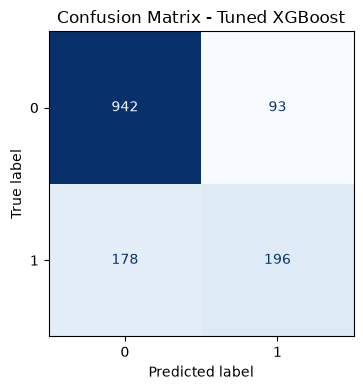

Logged MLflow run: 09291992e86f462eb9db326a5523973a


,accuracy,precision,recall,f1,roc_auc,brier_score,contacted_customers,true_churn_customers_contacted,non_churn_customers_contacted,missed_churn_customers,expected_net_value,realized_net_value_for_backtest,run_id,run_name
0,0.807665,0.678201,0.524064,0.591252,0.846698,0.134951,228,160,68,214,2789.777344,3000.0,09291992e86f462eb9db326a5523973a,xgboost_tuned_20260618_103021


In [7]:
run_name = f"xgboost_tuned_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

model = XGBClassifier(**xgb_params)

with mlflow.start_run(run_name=run_name) as run:
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = evaluate_model(y_test, y_pred, y_proba)
    business_kpis = calculate_business_kpi(y_test, y_proba, BUSINESS_PARAMS)

    mlflow.log_params(selected_params)
    mlflow.log_params(BUSINESS_PARAMS)
    mlflow.log_metrics(metrics)
    mlflow.log_metrics(business_kpis)
    mlflow.set_tags(
        {
            "project": "telco_churn",
            "stage": "model_development",
            "model_family": "xgboost",
            "data_split": "processed_train_test_from_notebook_03",
            "source_notebook": "07_mlflow_experiment_tracking.ipynb",
        }
    )

    metrics_path = REPORTS_DIR / "07_mlflow_xgboost_metrics.csv"
    predictions_path = REPORTS_DIR / "07_mlflow_xgboost_predictions.csv"
    confusion_matrix_path = REPORTS_DIR / "07_mlflow_confusion_matrix.png"

    metrics_table = pd.DataFrame([{**metrics, **business_kpis, "run_id": run.info.run_id, "run_name": run_name}])
    metrics_table.to_csv(metrics_path, index=False)

    predictions = test_metadata.copy()
    predictions["y_true"] = y_test.to_numpy()
    predictions["y_pred"] = y_pred
    predictions["churn_probability"] = y_proba
    predictions.to_csv(predictions_path, index=False)

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", ax=ax, colorbar=False)
    ax.set_title("Confusion Matrix - Tuned XGBoost")
    fig.tight_layout()
    fig.savefig(confusion_matrix_path, dpi=150)
    plt.show()

    mlflow.log_artifact(metrics_path, artifact_path="reports")
    mlflow.log_artifact(predictions_path, artifact_path="reports")
    mlflow.log_artifact(confusion_matrix_path, artifact_path="figures")
    mlflow.xgboost.log_model(model, name="model")

    run_id = run.info.run_id

print(f"Logged MLflow run: {run_id}")
metrics_table

## 8. Inspect Runs from Python

The UI is usually the most convenient way to inspect experiments. We can also query runs directly from Python, which is useful for reports or later automation.

In [8]:
experiment = mlflow.get_experiment_by_name("telco-churn")
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.f1 DESC"],
)

columns_to_show = [
    "run_id",
    "tags.mlflow.runName",
    "metrics.f1",
    "metrics.roc_auc",
    "metrics.precision",
    "metrics.recall",
    "metrics.expected_net_value",
    "metrics.realized_net_value_for_backtest",
]

runs[columns_to_show].head()

,run_id,tags.mlflow.runName,metrics.f1,metrics.roc_auc,metrics.precision,metrics.recall,metrics.expected_net_value,metrics.realized_net_value_for_backtest
0,09291992e86f462eb9db326a5523973a,xgboost_tuned_20260618_103021,0.591252,0.846698,0.678201,0.524064,2789.777344,3000.0


## 9. From Tracking to Artifact Management

MLflow helps us move from scattered notebook outputs to a structured experiment record.

In this notebook, the model is logged as an MLflow model artifact. That means MLflow stores not only the serialized model, but also metadata about how it can be loaded again. This becomes important when we later serve the model through an API.

For a larger production setup, we would usually add stronger model governance: model versions, approval states, deployment environments, owners, and rollback rules. For this course project, the important step is the shift from manual files to traceable model artifacts.

In [9]:
model_uri = f"runs:/{run_id}/model"
loaded_model = mlflow.xgboost.load_model(model_uri)
loaded_predictions = loaded_model.predict(X_test.head(5))

print("Model URI:", model_uri)
print("Predictions for first five test rows:", loaded_predictions.tolist())

Model URI: runs:/09291992e86f462eb9db326a5523973a/model
Predictions for first five test rows: [0, 1, 0, 0, 0]


## 10. Reflection

MLflow does not make a weak evaluation setup better. It records what happened. The quality of the experiment still depends on good data preparation, realistic validation, meaningful metrics, clear business assumptions, and a consistent evaluation function.

The practical benefit is traceability. If a result is discussed later, we can inspect the parameters, metrics, artifacts, and model version that produced it. This is the bridge from exploratory notebook work toward a reproducible ML workflow.

In this notebook, MLflow runs locally. That is useful for learning and for small individual projects. In a team setting, the tracking server is usually set up centrally so that everyone can access the same experiments, compare runs, and avoid separate local experiment histories. A central setup also makes it easier to connect experiment tracking with model registry, review processes, and deployment decisions.